# Notebook 01: Data Loading, Target Creation, Merge, and Minimal EDA

This notebook performs the first required stages of the thesis pipeline:

1. Load the private Banner and Moodle datasets.
2. Perform essential data quality checks.
3. Create the binary academic risk target.
4. Validate and clean the anonymised student key.
5. Keep students present in both datasets using a one to one inner join.
6. Show the target and risk source distributions.
7. Save the merged private dataset for Notebook 02.

Preprocessing, leakage removal, feature engineering, outlier analysis, and modelling are handled in later notebooks.

## 1. Imports and project paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

BANNER_FILE = RAW_DATA_DIR / "banner.csv"
MOODLE_FILE = RAW_DATA_DIR / "moodle.csv"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GPA_SOURCE = "end_term_gpa_range"
REGISTERED_CREDITS = "registered_credits"
EARNED_CREDITS = "earned_credits_this_semester"
STUDENT_KEY = "student_key"
TARGET = "academic_risk_label"

print("Project directory:", PROJECT_DIR)

Project directory: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks


## 2. Load and standardise Banner and Moodle

In [2]:
banner = pd.read_csv(BANNER_FILE)
moodle = pd.read_csv(MOODLE_FILE)

for df in (banner, moodle):
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

print("Banner shape:", banner.shape)
print("Moodle shape:", moodle.shape)

Banner shape: (3916, 24)
Moodle shape: (3770, 12)


## 3. Essential raw data checks


In [3]:
required_banner = {
    GPA_SOURCE,
    REGISTERED_CREDITS,
    EARNED_CREDITS,
    STUDENT_KEY,
}

missing_banner = sorted(
    required_banner - set(banner.columns)
)

if missing_banner:
    raise KeyError(
        f"Missing required Banner columns: {missing_banner}"
    )

if STUDENT_KEY not in moodle.columns:
    raise KeyError(
        f"Missing Moodle key column: {STUDENT_KEY}"
    )

quality_check = pd.DataFrame({
    "dataset": ["Banner", "Moodle"],
    "rows": [len(banner), len(moodle)],
    "columns": [banner.shape[1], moodle.shape[1]],
    "exact_duplicate_rows": [
        int(banner.duplicated().sum()),
        int(moodle.duplicated().sum()),
    ],
    "missing_student_keys": [
        int(banner[STUDENT_KEY].isna().sum()),
        int(moodle[STUDENT_KEY].isna().sum()),
    ],
})

display(quality_check)

,dataset,rows,columns,exact_duplicate_rows,missing_student_keys
0,Banner,3916,24,0,0
1,Moodle,3770,12,0,0


## 4. Create the academic risk target

A student is labelled **at risk** when either:

- the end term GPA band is below 2.25, or
- registered credits minus earned credits is greater than 15.

Target:

- `1` = At risk
- `0` = Not at risk

Rows where both target sources are missing are excluded because the target cannot be determined.

In [4]:
banner[GPA_SOURCE] = (
    banner[GPA_SOURCE]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(" ", "_", regex=False)
)

banner[REGISTERED_CREDITS] = pd.to_numeric(
    banner[REGISTERED_CREDITS],
    errors="coerce",
)

banner[EARNED_CREDITS] = pd.to_numeric(
    banner[EARNED_CREDITS],
    errors="coerce",
)

AT_RISK_GPA_BINS = {
    "0.00_TO_<1.00",
    "1.00_TO_<2.00",
    "2.00_TO_<2.25",
}

gpa_flag = banner[GPA_SOURCE].isin(
    AT_RISK_GPA_BINS
)

banner["credit_deficit"] = (
    banner[REGISTERED_CREDITS]
    - banner[EARNED_CREDITS]
)

credit_flag = (
    banner["credit_deficit"] > 15
)

gpa_valid = banner[GPA_SOURCE].notna()
credit_valid = banner["credit_deficit"].notna()
both_missing = ~gpa_valid & ~credit_valid

banner[TARGET] = np.where(
    both_missing,
    np.nan,
    (gpa_flag | credit_flag).astype(int),
)

banner["risk_source"] = np.select(
    [
        gpa_flag & credit_flag,
        gpa_flag & ~credit_flag,
        ~gpa_flag & credit_flag,
        both_missing,
    ],
    [
        "GPA and credit deficit",
        "GPA only",
        "Credit deficit only",
        "Missing both sources",
    ],
    default="Not at risk",
)

print(
    "Rows with unavailable target:",
    int(banner[TARGET].isna().sum()),
)

banner = (
    banner
    .dropna(subset=[TARGET])
    .copy()
)

banner[TARGET] = (
    banner[TARGET]
    .astype(int)
)

print(
    "Banner rows after removing unavailable targets:",
    len(banner),
)

Rows with unavailable target: 41
Banner rows after removing unavailable targets: 3875


## 5. Validate target definition

In [5]:
target_summary = (
    banner[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not at risk", 1: "At risk"})
    .rename_axis("risk_class")
    .to_frame("students")
)

target_summary["percentage"] = (
    target_summary["students"]
    / len(banner)
    * 100
).round(2)

risk_source_summary = (
    banner["risk_source"]
    .value_counts()
    .rename_axis("risk_source")
    .to_frame("students")
)

display(target_summary)
display(risk_source_summary)

,students,percentage
risk_class,,
Not at risk,2838,73.24
At risk,1037,26.76


,students
risk_source,
Not at risk,2838
GPA and credit deficit,593
GPA only,432
Credit deficit only,12


## 6. Clean and validate anonymised student keys


In [6]:
for df in (banner, moodle):
    df[STUDENT_KEY] = (
        df[STUDENT_KEY]
        .astype("string")
        .str.strip()
        .str.upper()
    )

banner = banner.dropna(
    subset=[STUDENT_KEY]
).copy()

moodle = moodle.dropna(
    subset=[STUDENT_KEY]
).copy()

banner_duplicate_keys = int(
    banner[STUDENT_KEY].duplicated().sum()
)

moodle_duplicate_keys = int(
    moodle[STUDENT_KEY].duplicated().sum()
)

if banner_duplicate_keys or moodle_duplicate_keys:
    raise ValueError(
        "Duplicate student_key values found. "
        "A one to one merge cannot be performed safely."
    )

banner_keys = set(banner[STUDENT_KEY])
moodle_keys = set(moodle[STUDENT_KEY])

print("Banner students:", len(banner_keys))
print("Moodle students:", len(moodle_keys))
print("Matched students:", len(banner_keys & moodle_keys))
print("Banner only:", len(banner_keys - moodle_keys))
print("Moodle only:", len(moodle_keys - banner_keys))

Banner students: 3875
Moodle students: 3770
Matched students: 3760
Banner only: 115
Moodle only: 10


## 7. Merge Banner and Moodle

In [7]:
merged = banner.merge(
    moodle,
    on=STUDENT_KEY,
    how="inner",
    suffixes=("_banner", "_moodle"),
    validate="one_to_one",
)

merge_check = pd.DataFrame({
    "check": [
        "Merged rows",
        "Unique students",
        "Duplicate student keys",
        "Missing target labels",
        "Exact duplicate rows",
    ],
    "value": [
        len(merged),
        merged[STUDENT_KEY].nunique(),
        int(merged[STUDENT_KEY].duplicated().sum()),
        int(merged[TARGET].isna().sum()),
        int(merged.duplicated().sum()),
    ],
})

display(merge_check)

,check,value
0,Merged rows,3760
1,Unique students,3760
2,Duplicate student keys,0
3,Missing target labels,0
4,Exact duplicate rows,0


## 8. Exploratory Data Analysis


,students,percentage
risk_class,,
Not at risk,2827,75.19
At risk,933,24.81


,students
risk_source,
Not at risk,2827
GPA and credit deficit,531
GPA only,390
Credit deficit only,12


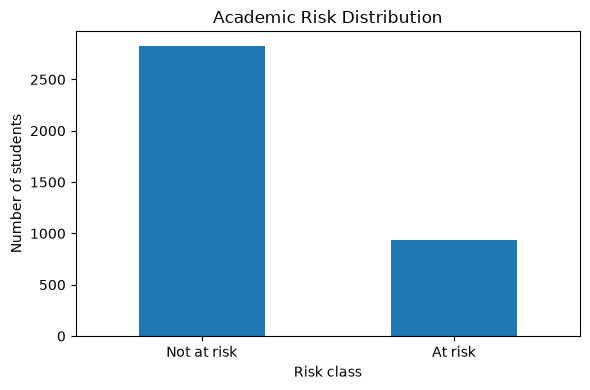

Saved figure: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\target_distribution.png


In [8]:
merged_target_summary = (
    merged[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not at risk", 1: "At risk"})
    .rename_axis("risk_class")
    .to_frame("students")
)

merged_target_summary["percentage"] = (
    merged_target_summary["students"]
    / len(merged)
    * 100
).round(2)

display(merged_target_summary)

display(
    merged["risk_source"]
    .value_counts()
    .rename_axis("risk_source")
    .to_frame("students")
)

ax = merged_target_summary["students"].plot(
    kind="bar",
    figsize=(6, 4),
)

ax.set_title("Academic Risk Distribution")
ax.set_xlabel("Risk class")
ax.set_ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()

figure_file = (
    FIGURES_DIR
    / "target_distribution.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", figure_file)

## 9. Save the merged private dataset

Final outcome and target construction fields remain in this private merged dataset for validation. 

In [9]:
output_file = (
    PROCESSED_DATA_DIR
    / "merged_banner_moodle_with_target.pkl"
)
csv_output_file = (
    PROCESSED_DATA_DIR
    / "merged_banner_moodle_with_target.csv"
)

merged.to_pickle(
    output_file
)
# Save as CSV
merged.to_csv(csv_output_file, index=False)

print("Pickle Saved:", output_file)
print("CSV Saved:", csv_output_file)
print("Final merged shape:", merged.shape)




Pickle Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\data\processed\merged_banner_moodle_with_target.pkl
CSV Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\data\processed\merged_banner_moodle_with_target.csv
Final merged shape: (3760, 38)


## Notebook 01 complete
